In [1]:
import torch
import torch.nn as nn


class Gemma4RMSNorm(nn.Module):
    def __init__(self, dim, eps, with_scale=True):
        super().__init__()
        self.eps = eps
        self.with_scale = with_scale

        if self.with_scale:
            self.weight = nn.Parameter(torch.ones(dim), requires_grad=True) # This is the learnable Parameter Gamma.

    def _norm(self, hidden_states):
        mean_squared = hidden_states.pow(2).mean(-1, keepdim=True) + self.eps # Mean Sqare
        return hidden_states * torch.pow(mean_squared, -0.5) # layer/root(mean_squared)

    def forward(self, hidden_states):
        normed_output = self._norm(hidden_states.float())
        if self.with_scale:
            normed_output *= self.weight.float()
        return normed_output.type_as(hidden_states)

In [2]:
toy_gemma4_rms = Gemma4RMSNorm(4,1e-6)
hidden_state_1 = torch.tensor([3,-1,4,0], dtype=torch.float16)
print(toy_gemma4_rms(hidden_state_1))

hidden_state_2 = torch.tensor([300,-100,400,0], dtype=torch.float16)
print(toy_gemma4_rms(hidden_state_2))

tensor([ 1.1768, -0.3923,  1.5693,  0.0000], dtype=torch.float16,
       grad_fn=<ToCopyBackward0>)
tensor([ 1.1768, -0.3923,  1.5693,  0.0000], dtype=torch.float16,
       grad_fn=<ToCopyBackward0>)


In [3]:
class Gemma4TextScaledWordEmbedding(nn.Embedding):
    # THis module overrides nn.Embeddings forward by multiplying with embedding scale

    def __init__(self, num_embeddings, embedding_dim, padding_idx, embed_scale=1.0):
        super().__init__(num_embeddings, embedding_dim, padding_idx)
        self.scalar_embed_scale = embed_scale
        self.register_buffer("embed_scale",torch.tensor(embed_scale), persistent=False)

    def forward(self, input_ids):
        return super().forward(input_ids) * self.embed_scale.to(self.weight.dtype)

class DiffusionGemmaTextScaledWordEmbedding(Gemma4TextScaledWordEmbedding):
    pass

In [4]:
vocab_size, dim, pad_idx = 6,4,0
embed_scale = 8.0

vanilla = nn.Embedding(vocab_size, dim, padding_idx=pad_idx) # padding will be excluded from the gradient update process

#Scaled embedding, with weights copied so we compare apples to apples
toy_gemma4_text_scaled_word_embedd = Gemma4TextScaledWordEmbedding(vocab_size,dim,pad_idx,embed_scale=embed_scale)
toy_gemma4_text_scaled_word_embedd.weight.data.copy_(vanilla.weight.data)

input_ids = torch.tensor([[1,2,3]])

vanilla_out = vanilla(input_ids)
scaled_out = toy_gemma4_text_scaled_word_embedd(input_ids)

print("Vanilla output:\n", vanilla_out, "\n")
print("Scaled output:\n", scaled_out, "\n")
print("Ratio (scaled / vanilla):\n", scaled_out/vanilla_out)

Vanilla output:
 tensor([[[ 0.3841, -0.9238,  1.0307, -0.2659],
         [-1.2881,  1.1119, -0.5522, -0.1917],
         [ 1.1631, -0.3538,  0.4934,  0.2512]]], grad_fn=<EmbeddingBackward0>) 

Scaled output:
 tensor([[[  3.0726,  -7.3905,   8.2456,  -2.1269],
         [-10.3049,   8.8953,  -4.4178,  -1.5333],
         [  9.3044,  -2.8303,   3.9470,   2.0094]]], grad_fn=<MulBackward0>) 

Ratio (scaled / vanilla):
 tensor([[[8., 8., 8., 8.],
         [8., 8., 8., 8.],
         [8., 8., 8., 8.]]], grad_fn=<DivBackward0>)


## Rotary Positional Embedding

- 2 types: default and propositional
- Only applied to Q and K, not applied to V
- cos and sin values are precomputed and are deterministic, applying it into the Q and K happens realtime.

In [5]:
import torch
from torch import nn

# THe Gemma way of Pairing. Rotating the Half of the embedding vector.
def rotate_half(x):
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2]
    return torch.cat([-x2,x1], dim=-1)

# The Matrix Formula
def apply_rotary_pos_emb(x, cos, sin, unsqueeze_dim=1):
    cos=cos.unsqueeze(unsqueeze_dim)
    sin = sin.unsqueeze(unsqueeze_dim)
    return (x*cos) + (rotate_half(x) * sin)

# This is the Default RoPE calculations
def compute_default_rope_parameters(config, layer_type, device=None):
    base = config.rope_parameters[layer_type]["rope_theta"]
    dim = getattr(config, "head_dim", None) or config.hidden_size // config.num_attention_heads
    inv_freq = 1.0 / (
        base ** (torch.arange(0, dim, 2, dtype=torch.int64).to(device=device, dtype=torch.float) / dim)
    )
    return inv_freq

# This is the Proportional RoPE
def compute_proportional_rope_parameters(config, layer_type, device=None):
    rope_params = config.rope_parameters[layer_type]
    head_dim = config.global_head_dim if layer_type == "full_attention" else config.head_dim
    base = rope_params["rope_theta"]
    rope_proportion = rope_params.get("partial_rotary_factor", 1.0)# We take from the parameters or default is 1.0
    rope_angles = int(rope_proportion * head_dim // 2)

    inv_freq_rotated = 1.0 / (
        base ** (torch.arange(0, 2 * rope_angles, 2, dtype=torch.int64).to(device=device, dtype=torch.float) / head_dim)
    )
    nope_angles = head_dim // 2 - rope_angles
    if nope_angles > 0:
        inv_freq = torch.cat([inv_freq_rotated, torch.zeros(nope_angles, dtype=torch.float32, device=device)])
    else:
        inv_freq = inv_freq_rotated
    return inv_freq


ROPE_INIT_FNS = {
    "default": compute_default_rope_parameters,
    "proportional": compute_proportional_rope_parameters,
}


class DiffusionGemmaTextRotaryEmbedding(nn.Module):
    def __init__(self, config, device=None):
        super().__init__()
        self.config = config
        # The Frequency Computation is deterministic so we use persistent=False. This means, the buffer does not get saved to state dict.
        # sliding_attention uses 'default RoPE' and full_attention uses 'proportional RoPE'
        # so we compute them separately and save them in buffers while intialising the model.
        for layer_type in set(config.layer_types):
            rope_type = config.rope_parameters[layer_type]["rope_type"]
            inv_freq = ROPE_INIT_FNS[rope_type](config, layer_type, device=device)
            self.register_buffer(f"{layer_type}_inv_freq", inv_freq, persistent=False)

    @torch.no_grad() # No gradient to be computed in RoPE, just adding positional info
    def forward(self, x, position_ids, layer_type):
        inv_freq = getattr(self, f"{layer_type}_inv_freq")# to check which rope to Use
        inv_freq_expanded = inv_freq[None, :, None].float().expand(position_ids.shape[0], -1, -1).to(x.device)
        position_ids_expanded = position_ids[:, None, :].float()

        freqs = (inv_freq_expanded @ position_ids_expanded).transpose(1,2)# Omega x m to get the unique angles
        emb = torch.cat((freqs, freqs), dim=-1)
        cos, sin = emb.cos(), emb.sin()
        return cos.to(dtype=x.dtype), sin.to(dtype=x.dtype)

## Grouped Query Attention

In [6]:
def repeat_kv(hidden_states, n_rep):
    # n_rep is the number of heads
    # We create a new dimension to duplicate the heads along to match the number of heads in queries
    # So we store only the x number of heads for K and V but compute as 2x number of heads
    # Its a computation trick essentially for Grouped Query Attention
    batch, num_key_value_heads, slen, head_dim = hidden_states.shape
    if n_rep == 1:
        return hidden_states
    hidden_states = hidden_states[:, :, None, :, :].expand(batch, num_key_value_heads, n_rep, slen, head_dim)
    return hidden_states.reshape(batch, num_key_value_heads * n_rep, slen, head_dim)

def eager_attention_forward(module, query, key, value, attention_mask, dropout=0.0, scaling=None):
    if scaling is None:# We can manually override the scalling
        scaling = module.head_dim**-0.5# This is the sqrt(d_k) scaling term in the original attention

    key_states = repeat_kv(key, module.num_key_value_groups)
    value_states = repeat_kv(value, module.num_key_value_groups)

    attn_weights = torch.matmul(query, key_states.transpose(2,3)) * scaling # (Q.K^T)/sqrt(d_k)
    if attention_mask is not None:
        attn_weights = attn_weights + attention_mask# for the -inf masking for causal attention

    attn_weights = nn.functional.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query.dtype)
    attn_weights = nn.functional.dropout(attn_weights, p=dropout, training=module.training)
    attn_output = torch.matmul(attn_weights, value_states)
    attn_output = attn_output.transpose(1,2).contiguous() #.contiguous(): makes sure the array's values are stored next to each other in one continuous block of memory, in C-style row-major order
    return attn_output, attn_weights# We return both, very useful for logging

In [7]:
toy_kv = torch.tensor([[[[1.0, 1.0]], [[2.0, 2.0]]]]) # (batch=1, kv_heads=2, seq=1, head_dim=2)
expanded = repeat_kv(toy_kv, n_rep=2)
print(expanded.squeeze())

tensor([[1., 1.],
        [1., 1.],
        [2., 2.],
        [2., 2.]])


## Text Side Encoder and Decoder Attention Block Diagrams

#### Encoder Text Attention
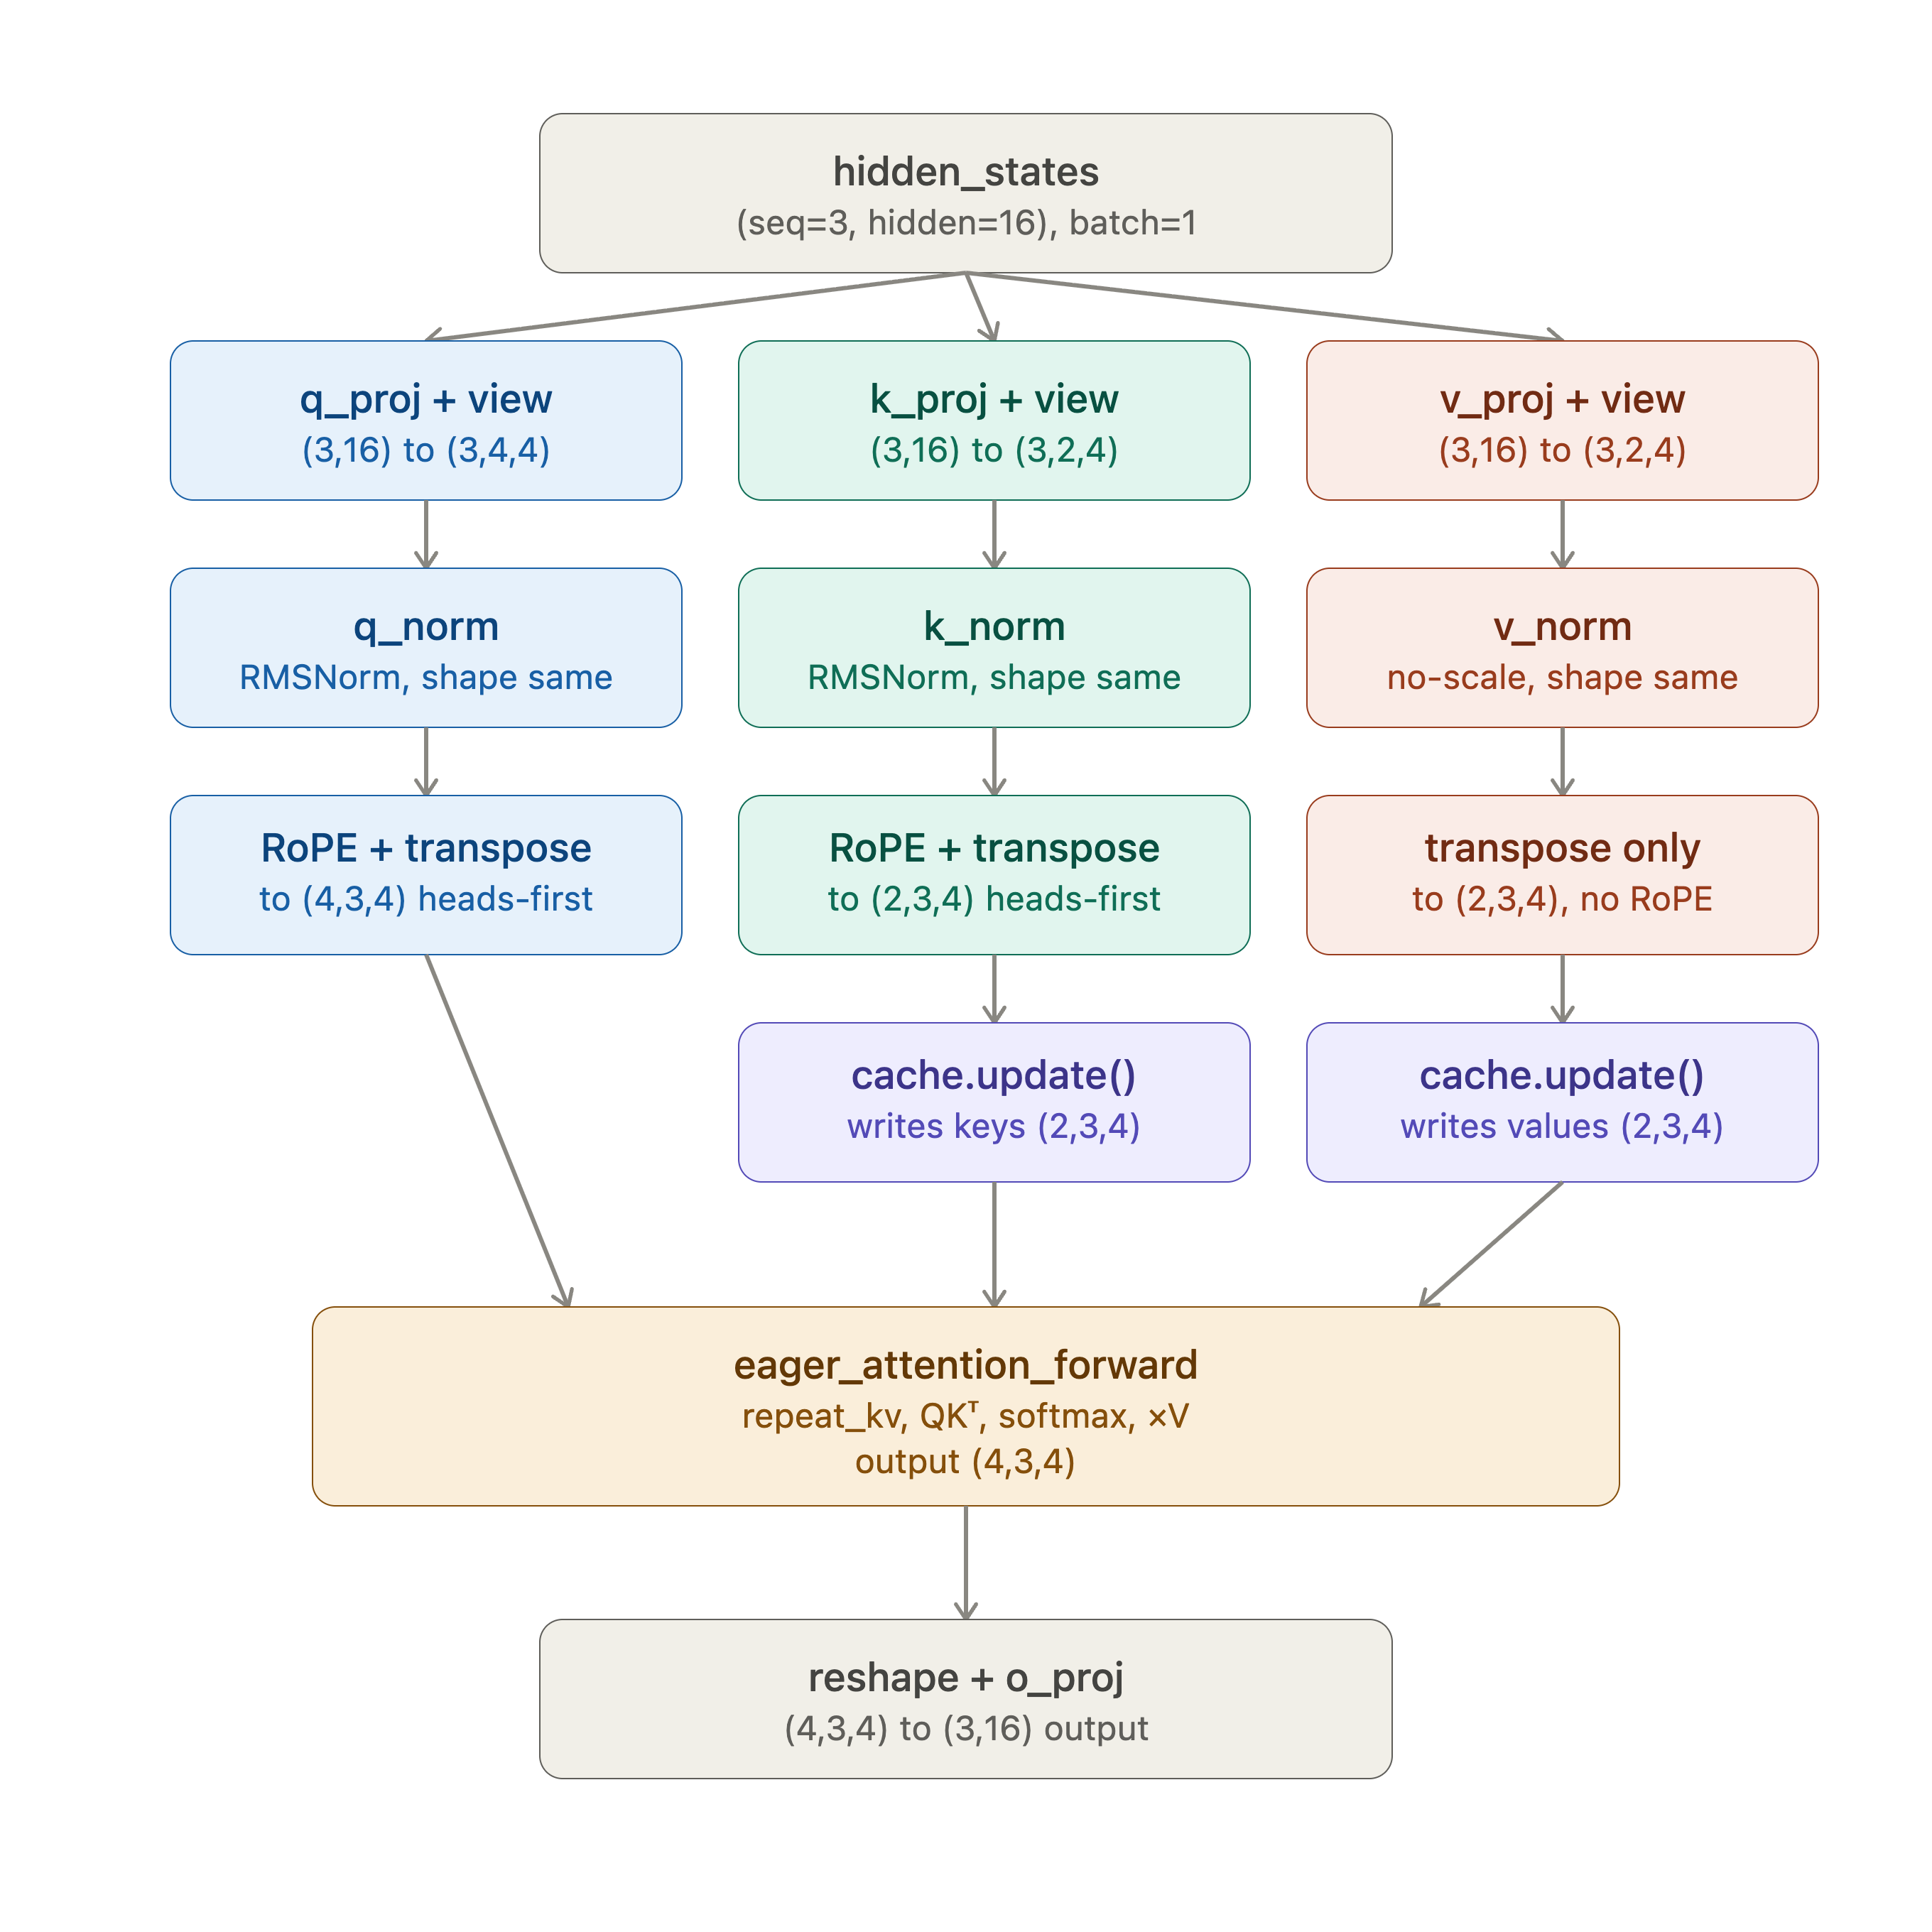

#### Decoder Text Attention
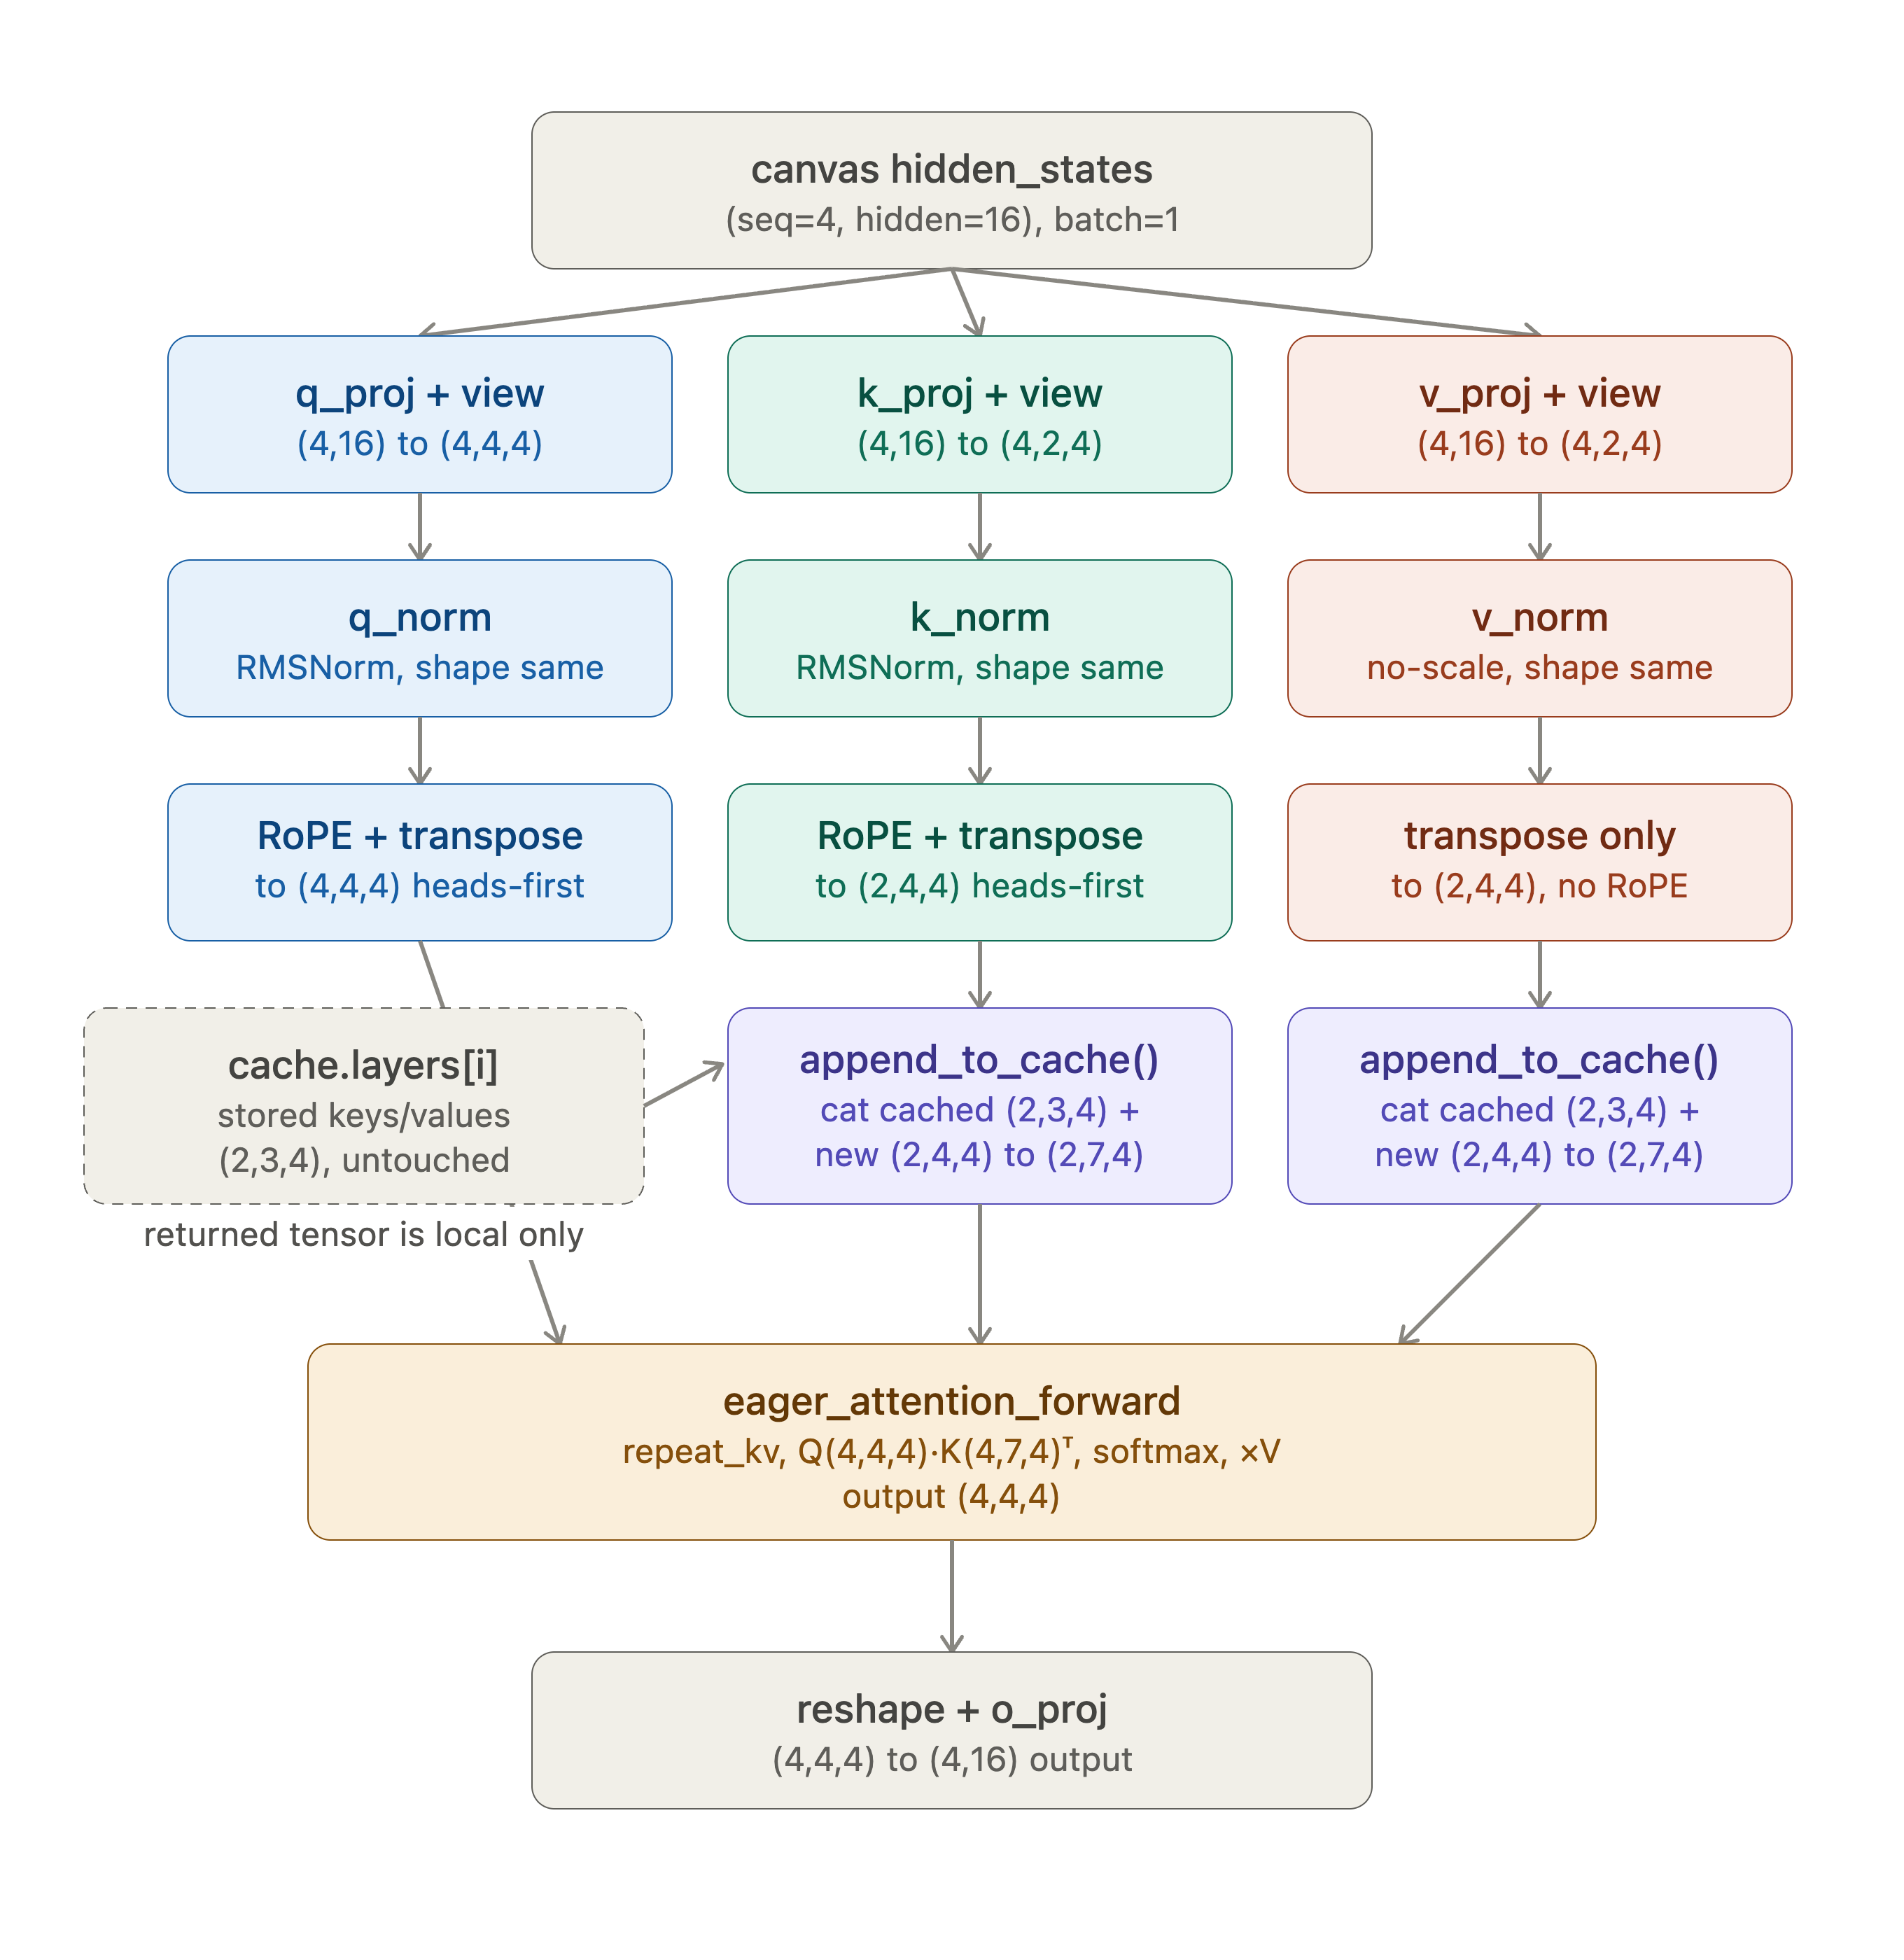

- In Diffusion Gemma there are 29 of these layers according to the Config.
- Encoder runs once and captures the K, V from each of the 29 layers.
- Decoder runs multiple times based on the number of denoising steps, but Encoder K, V values are only computed once.
- The decoder purely reads the cache and appends the canvas/output tokens to it but DOES NOT modify the cache
- The K,V cache from each layer of the encoder is concatenated with the K, V of the decoder along the seq_len dimension.
- The dimension gets collapsed under the matrix multiplication so we don't need to worry about any dimensional mismatch.

        IMPORTANT NOTE: Encoder Attention uses Causal Attention (default or sliding based on layer type) but Decoder Attention is bidirectional and does not use any masking because Decoder is generating all tokens at once, we dont really need a causal mask. Encoder however sees teh prompt and we obviously wrote one token after another in the prompt so it makes sense to use causal mask for its attention.

In [8]:
class DiffusionGemmaEncoderTextAttention(nn.Module):
    def __init__(self, config, layer_idx):
        super().__init__()
        self.is_causal = config.use_bidirectional_attention != "all"
        self.config = config
        self.layer_idx = layer_idx
        self.layer_type = config.layer_types[layer_idx]
        self.is_sliding = self.layer_type == "sliding_attention"
        self.sliding_window = config.sliding_window if self.is_sliding else None

        self.head_dim = config.global_head_dim if not self.is_sliding and config.global_head_dim else config.head_dim
        num_key_value_heads = config.num_global_key_value_heads if not self.is_sliding else config.num_key_value_heads
        self.num_key_value_groups = config.num_attention_heads // num_key_value_heads
        self.scaling = 1.0
        self.attention_dropout = config.attention_dropout

        self.q_proj = nn.Linear(config.hidden_size, config.num_attention_heads * self.head_dim, bias = config.attention_bias)
        self.k_proj = nn.Linear(config.hidden_size, num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.v_proj = (
            nn.Linear(config.hidden_size, num_key_value_heads * self.head_dim, bias=config.attention_bias)
            if self.is_sliding else None
        )
        self.o_proj = nn.Linear(config.num_attention_heads * self.head_dim, config.hidden_size, bias=config.attention_bias)

        self.q_norm = Gemma4RMSNorm(self.head_dim, eps=config.rms_norm_eps)
        self.k_norm = Gemma4RMSNorm(self.head_dim, eps=config.rms_norm_eps)
        self.v_norm = Gemma4RMSNorm(self.head_dim, eps=config.rms_norm_eps, with_scale=False)


    def forward(self, hidden_states, position_embeddings, attention_mask, past_key_values=None):
        input_shape = hidden_states.shape[:-1]
        hidden_shape = (*input_shape, -1, self.head_dim)
        cos, sin = position_embeddings

        query_states = self.q_norm(self.q_proj(hidden_states).view(hidden_shape))
        query_states = apply_rotary_pos_emb(query_states, cos, sin, unsqueeze_dim=2).transpose(1,2)

        key_states = self.k_proj(hidden_states).view(hidden_shape)# To change the shape for Multihead
        value_states = self.v_proj(hidden_states).view(hidden_shape) if self.v_proj is not None else key_states# To change the shape for Multihead

        key_states = self.k_norm(key_states)
        key_states = apply_rotary_pos_emb(key_states, cos, sin, unsqueeze_dim=2).transpose(1,2)
        value_states = self.v_norm(value_states).transpose(1,2)

        # This is the part where we store each K and V of the encoder so that we can pass this onto each layer of the decoder
        if past_key_values is not None:
            key_states, value_states = past_key_values.update(key_states, value_states, self.layer_idx)

        attn_output, attn_weights = eager_attention_forward(
            self, query_states, key_states, value_states, attention_mask,
            dropout=self.attention_dropout if self.training else 0.0, scaling=self.scaling,
        )
        attn_output = attn_output.reshape(*input_shape, -1).contiguous()
        return self.o_proj(attn_output), attn_weights


class DiffusionGemmaDecoderTextAttention(nn.Module):
    def __init__(self, config, layer_idx):
        super().__init__()
        self.is_causal = False
        self.config = config
        self.layer_idx = layer_idx
        self.layer_type = config.layer_types[layer_idx]
        self.is_sliding = self.layer_type == "sliding_attention"
        self.sliding_window = config.sliding_window if self.is_sliding else None

        self.head_dim = config.global_head_dim if not self.is_sliding and config.global_head_dim else config.head_dim
        num_key_value_heads = config.num_global_key_value_heads if not self.is_sliding else config.num_key_value_heads
        self.num_key_value_groups = config.num_attention_heads // num_key_value_heads
        self.scaling = 1.0
        self.attention_dropout = config.attention_dropout

        self.q_proj = nn.Linear(config.hidden_size, config.num_attention_heads * self.head_dim, bias = config.attention_bias)
        self.k_proj = nn.Linear(config.hidden_size, num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.v_proj = (
            nn.Linear(config.hidden_size, num_key_value_heads * self.head_dim, bias=config.attention_bias)
            if self.is_sliding else None
        )
        self.o_proj = nn.Linear(config.num_attention_heads * self.head_dim, config.hidden_size, bias=config.attention_bias)

        self.q_norm = Gemma4RMSNorm(self.head_dim, eps=config.rms_norm_eps)
        self.k_norm = Gemma4RMSNorm(self.head_dim, eps=config.rms_norm_eps)
        self.v_norm = Gemma4RMSNorm(self.head_dim, eps=config.rms_norm_eps, with_scale=False)


    def forward(self, hidden_states, position_embeddings, attention_mask, past_key_values=None):
        input_shape = hidden_states.shape[:-1]
        hidden_shape = (*input_shape, -1, self.head_dim)
        cos, sin = position_embeddings

        query_states = self.q_norm(self.q_proj(hidden_states).view(hidden_shape))
        query_states = apply_rotary_pos_emb(query_states, cos, sin, unsqueeze_dim=2).transpose(1,2)

        key_states = self.k_proj(hidden_states).view(hidden_shape)# To change the shape for Multihead
        value_states = self.v_proj(hidden_states).view(hidden_shape) if self.v_proj is not None else key_states# To change the shape for Multihead

        key_states = self.k_norm(key_states)
        key_states = apply_rotary_pos_emb(key_states, cos, sin, unsqueeze_dim=2).transpose(1,2)
        value_states = self.v_norm(value_states).transpose(1,2)

        # This is the part where we read the encoder cached K and V values
        # This is the part where we store each K and V of the encoder so that we can pass this onto each layer of the decoder
        if past_key_values is not None:
            key_states, value_states = self.append_to_cache(past_key_values, key_states, value_states)

        attn_output, attn_weights = eager_attention_forward(
            self, query_states, key_states, value_states, attention_mask,
            dropout=self.attention_dropout if self.training else 0.0, scaling=self.scaling,
        )
        attn_output = attn_output.reshape(*input_shape, -1).contiguous()
        return self.o_proj(attn_output), attn_weights

    def append_to_cache(self, past_key_values, key_states, value_states):
        # We read the K,V of the exact layer from 'past_key_values'
        cache_layer = past_key_values.layers[self.layer_idx]
        # Each cache K, V would have a dimension (batch_size, num_kv_heads, num_prompt_tokens, head_dim)
        # so dim=-2 refers to num_prompt_tokens dimension
        # So we take the K and V from the decoder canvas tokens and concatenate them with KV from encoder along dim=-2
        keys = torch.cat([cache_layer.keys, key_states], dim=-2)
        values = torch.cat([cache_layer.values, value_states], dim=-2)
        return keys, values

# Text Router and Text Expert

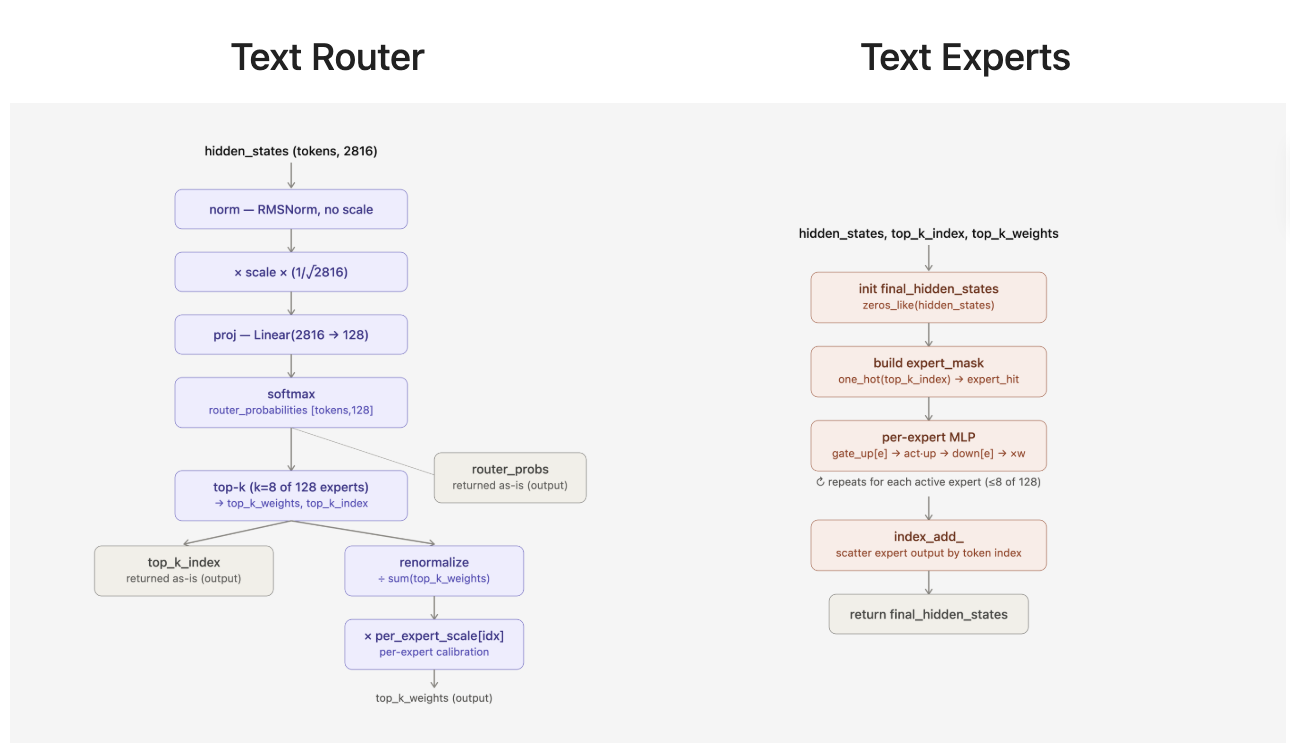


- Note that the Text Router and the Text Expert gets a flattend version of the hidden states.
- So what would normally be (batch_size, seq_len, hidden_dim) becomes (batch_size*seq_len, hidden_dim)
- SiLU is NOT used in diffusion gemma, its just there to show how to deal with a config that might have multiple activations.
- We will see this later but in Diffusion Gemma, Experts and Routers share the "EXACT" same weights in both Encoder and Decoder.
- The router's whole job is producing that per-token expert selection + blend weights.
- The experts module's whole job is executing that expert selection as efficiently as possible — by grouping w.r.t expert rather than by token, so no compute is ever spent on a experts nobody asked for, and every expert that is asked for runs once as a batch, no matter how many unrelated tokens asked for it.

In [9]:
def gelu_pytorch_tanh(x):
    return nn.functional.gelu(x, approximate="tanh")

ACT2FN = {
    "gelu_pytorch_tanh": gelu_pytorch_tanh,
    "silu": nn.functional.silu, # kept in case another config path needs it later
}

class Gemma4TextRouter(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.scaler_root_size = self.hidden_size**-0.5
        self.eps = config.rms_norm_eps

        self.norm = Gemma4RMSNorm(self.hidden_size, eps=self.eps, with_scale=False)
        self.proj = nn.Linear(config.hidden_size, config.num_experts, bias=False)
        self.scale = nn.Parameter(torch.ones(self.hidden_size))
        self.per_expert_scale = nn.Parameter(torch.ones(config.num_experts))# learnable scale for the output of each expert

    def forward(self, hidden_states):
        # The input to Text Router is a flattened hidden state.
        # The router doesn't care about sequence structure at all.
        # It treats every token in the batch as an independent row to be routed.
        hidden_states = self.norm(hidden_states)
        hidden_states = hidden_states * self.scale * self.scaler_root_size
        # hidden_states is -> (batch_size*seq_len, hidden_dim) and proj is (hidden_dim, num_experts)
        expert_scores = self.proj(hidden_states) # (batch_size*seq_len, num_experts)
        # So each of your tokens now has a probability distribution over all 128 experts => "how relevant is each expert to this token"
        router_probabilities = nn.functional.softmax(expert_scores, dim=-1, dtype=torch.float32)# Now each token has experts that sum to 1
        # Now we will index only the top-k experts and throw away the rest for each token
        top_k_weights, top_k_index = torch.topk(
            router_probabilities, k=self.config.top_k_experts, dim=-1,
        )# (batch_size*seq_len, top_k)
        top_k_weights = top_k_weights / top_k_weights.sum(dim=-1, keepdim=True)# renormalize just the top k experts
        top_k_weights = top_k_weights * self.per_expert_scale[top_k_index]# learned per-expert scaling parameter
        return router_probabilities, top_k_weights, top_k_index


class Gemma4TextExperts(nn.Module):
    """Collection of expert weights stored as 3D tensors."""

    def __init__(self, config):
        super.__init__()
        self.num_experts = config.num_experts
        self.hidden_dim = config.hidden_size
        self.intermediate_dim = config.moe_intermediate_size
        # Each expert is a MLP that transforms hidden_dim -> 2*intermediate_dim and then back to hidden_dim
        self.gate_up_proj = nn.Parameter(torch.empty(self.num_experts, 2*self.intermediate_dim, self.hidden_dim))
        self.down_proj = nn.Parameter(torch.empty(self.num_experts, self.hidden_dim, self.intermediate_dim))
        self.act_fn = ACT2FN(config.hidden_activation)

    def forward(self, hidden_states, top_k_index, top_k_weights):
        final_hidden_states = torch.zeros_like(hidden_states)# starts as all zeros with dim same as (batch*seq_len, hidden_dim)

        with torch.no_grad():
            expert_mask = nn.functional.one_hot(top_k_index, num_classes=self.num_experts)# which experts were picked by each token(batch_size*seq_len, top_k, num_experts)
            # Permute is how we interchange the token and expert dimension
            expert_mask = expert_mask.permute(2,1,0)# (num_experts, top_k, batch_size*seq_len)
            expert_hit = torch.greater(expert_mask.sum(dim=(-1, -2)), 0).nonzero()# only the experts that got picked by AT LEAST one of our tokens

        #We need to change the grouping of the tensor from based off of tokens-> based off of experts
        for expert_idx in expert_hit:#Each expert gets its own MLP but only if that expert was picked even by a single token
            expert_idx = expert_idx[0]
            top_k_pos, token_idx = torch.where(expert_mask[expert_idx])# which tokens have this expert anywhere in their chosen set
            current_state = hidden_states[token_idx]# We take all tokens that selected a specific expert
            # because once  we are inside an expert's forward pass, all tokens that chose the expert are about to go through the identical gate_up_proj[expert] and down_proj[expert] weights

            gate, up = nn.functional.linear(current_state, self.gate_up_proj[expert_idx]).chunk(2, dim=-1)
            current_hidden_states = self.act_fn(gate) * up
            current_hidden_states = nn.functional.linear(current_hidden_states, self.down_proj[expert_idx])
            #Once we have passed all the tokens that chose an expert and pass them through the expert's MLP we weigh them with their softmax scores
            current_hidden_states = current_hidden_states * top_k_weights[token_idx, top_k_pos, None] # What weights did token X give to whichever expert sat at rank-position Y
            # along dimension 0, for each row i in values, add it into final_hidden_states[token_idx[i]]
            # it places each token's weighted expert-1 output back into that token's own row
            final_hidden_states.index_add_(0, token_idx, current_hidden_states.to(final_hidden_states.dtype))

        return final_hidden_states

# This is the MLP that runs in parallel on the same input as the router & expert but its NOT the flattened version.
class DiffusionGemmaText4MLP(nn.Module):
    def __init__(self, config, layer_idx):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.intermediate_size = config.intermediate_size
        self.gate_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=False)
        self.up_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=False)
        self.down_proj = nn.Linear(self.intermediate_size, self.hidden_size, bias=False)
        self.act_fn = ACT2FN[config.hidden_activation]

    def forward(self, x):
        return self.down_proj(self.act_fn(self.gate_proj(x)) * self.up_proj(x))


class DiffusionGemmaTextRouter(Gemma4TextRouter):
    pass


class DiffusionGemmaTextExperts(Gemma4TextExperts):
    pass

# Causal Mask vs Sliding Window Causal Mask

There are 2 types of masking that we will see in this model. THe masking is chosen based on layer type from config

- create_causal_mask -> standard lower-triangular causal mask. Query position i can see every key position < i, and nothing more is ever blocked. THe allowed region only grows as you go down rows. This is what "full attention" layers use.
- create_sliding_window_causal_mask → causal plus a band limit. Query position i can only see keys within sliding_window positions behind it (kv_idx > q_idx - sliding_window, from the actual source's sliding_window_overlay), combined with the ordinary causal constraint via and_masks. The attendable region becomes a diagonal band, not a full triangle.

NOTE: Both these functions are already defined in the transformers library so we import them(from transformers.masking_utils import create_causal_mask, create_sliding_window_causal_mask). We can define it ourselves, its just a mask.

In [ ]:
class DiffusionGemmaEncoderTextLayer(nn.Module):
    def __init__(self, config, layer_idx):
        super.__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.layer_idx = layer_idx
        self.self_attn = DiffusionGemmaEncoderTextAttention(config=config, layer_idx=layer_idx) #This writes to cache
        self.mlp = DiffusionGemmaText4MLP(config, layer_idx)
        self.input_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.post_attention_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.pre_feedforward_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.post_feedforward_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        # Right now all layer_scale are 1 so it really doesn't "do" anything, but later we can change this
        # So having this here keeps things flexible
        self.register_buffer("layer_scalar", torch.ones(1))# This gets stored into the state_dict unlike the RoPE buffer

        self.router = DiffusionGemmaTextRouter(config)
        self.experts = DiffusionGemmaTextExperts(config)
        self.post_feedforward_layernorm_1 = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.post_feedforward_layernorm_2 = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.pre_feedforward_layernorm_2 = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)

    def forward(self, hidden_states, position_embddings=None, attention_mask=None, past_key_values=None):
        residual = hidden_states # THis is the input to the attention block
        hidden_states = self.input_layernorm(hidden_states)# norm
        # Attention calculation
        hidden_states, _ = self.self_attn(
            hidden_states=hidden_states,
            position_embddings=position_embddings,
            attention_mask=attention_mask,
            past_key_values=past_key_values,
        )
        # We refer to the next 2 lines together as add & norm, very common in attention architecture
        # Its the skip connection from the first hidden state to the normed post attention hidden state
        hidden_states = self.post_attention_layernorm(hidden_states)#norm
        hidden_states = residual + hidden_states# skip connection

        residual = hidden_states# saving for the next skip connection
        # Now we go through the 2 parallel branches of the block
        # The dense MLP and teh MoE(Router + Experts)
        hidden_states = self.pre_feedforward_layernorm(hidden_states)
        hidden_states = self.mlp(hidden_states)
        hidden_states_1 = self.post_feedforward_layernorm_1(hidden_states) # Branch A: dense MLP

        hidden_states_flat = residual.reshape(-1, residual.shape[-1])
        hidden_states_2_for_routing = hidden_states_flat
        hidden_states_2_for_experts = self.pre_feedforward_layernorm_2(hidden_states_flat)
        _, top_k_weights, top_k_index = self.router(hidden_states_2_for_routing)# calculates top-k experts for each token
        hidden_states_2 = self.experts(hidden_states_2_for_experts, top_k_index, top_k_weights)# passes and weighs each expert for all tokens
        hidden_states_2 = hidden_state_2.reshape(residual.shape)
        hidden_states_2 = self.post_feedforward_layernorm_2(hidden_states_2) # Branch B: MoE

        hidden_states = hidden_states_1 + hidden_states_2# Both the parallel branches get summed together
        hidden_states = self.post_feedforward_layernorm(hidden_states)
        hidden_states = residual + hidden_states

        hidden_states = hidden_states * self.layer_scalar
        return hidden_states


from transformers.cache_utils import DynamicCache
from transformers.masking_utils import create_causal_mask, create_sliding_window_causal_mask
from collections import namedtuple

EncoderOutput = namedtuple("EncoderOutput", ["last_hidden_state", "past_key_values"])# Following same convention as the transformer models

class DiffusionGemmaEncoderTextModel(nn.Module):
    """embed_tokens -> stack of DiffusionGemmaEncoderTextLayer -> final norm.
    Runs once per new prompt, filling the KV cache the decoder will later read from."""

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.padding_idx = config.pad_token_id
        self.vocab_size = config.vocab_size

        self.embed_tokens = DiffusionGemmaTextScaledWordEmbedding(
            config.vocab_size, config.hidden_size, self.padding_idx, embed_scale=config.hidden_size**0.5
        )
        #We stack 'DiffusionGemmaEncoderTextLayer' layers to create the Encoder model while caching each layer
        self.layers = nn.ModuleList(
            [DiffusionGemmaEncoderTextLayer(config, layer_idx) for layer_idx in range(config.num_hidden_layers)]
        )
        self.norm = Gemma4RMSNorm(config.hidden_size, eps=config.rms_norm_eps)
        self.rotatory_emb = DiffusionGemmaTextRotaryEmbedding(config)
        self.unique_layer_types = set(config.layer_types)

    def forward(self, input_ids=None, attention_mask=None, position_ids=None, past_key_values=None, inputs_embeds=None):
        inputs_embeds = self.embed_tokens(input_ids)# Pass tokens to embedding layer

        if past_key_values is None:
            past_key_values = DynamicCache(config=self.config)# To initialize the KV cache for each layer

        if position_ids is None:
            past_seen_tokens = past_key_values.get_seq_length() if past_key_values is not None else 0
            position_ids = torch.arange(inputs_embeds.shape[1], device=inputs_embeds.device) + past_seen_tokens
            position_ids = position_ids.unsqueeze(0)

        if not isinstance(attention_mask, dict):
            mask_kwargs = {
                "config": self.config,
                "inputs_embeds": inputs_embeds,
                "attention_mask": attention_mask,
                "past_key_values": past_key_values,
                "position_ids": position_ids,
            }
            causal_mask_mapping = {
                "full_attention": create_causal_mask(**mask_kwargs),
                "sliding_attention": create_sliding_window_causal_mask(**mask_kwargs),
            }
        else:
            causal_mask_mapping = attention_mask

        hidden_states = inputs_embeds
        position_embeddings = {}
        for layer_type in self.unique_layer_types:
            position_embeddings[layer_type] = self.rotatory_emb(hidden_states, position_ids, layer_type)# keeping PE ready

        # Now that we have RoPE cos and sin ready for each layer, we go through each layer and forward pass.
        # At each layer we apply the RoPE values to Q and K and cache the K and V values.
        for i, encoder_layer in enumerate(self.layers[:, self.config.num_hidden_layers]):
            layer_type = self.config_layer_types[i]
            p= next(encoder_layer.parameters())
            hidden_states = hidden_states.to(device=p.device, dtype=p.dtype)
            cos, sin = position_embeddings[layer_type]
            mask = causal_mask_mapping[layer_type]
            hidden_states = encoder_layer(
                hidden_states,
                position_embeddings=(cos.to(p.device), sin.to(p.device)),
                attention_mask=None if mask is None else mask.to(p.device),
                past_key_values=past_key_values,
            )
        hidden_states = self.norm(hidden_states.to(self.norm.weight.device))

        return EncoderOutput(last_hidden_state=hidden_states, past_key_values=past_key_values)


class DiffusionGemmaEncoderModel(nn.Module):
    """Wraps DiffusionGemmaEncoderTextModel under `.language_model`, matching the actual Diffusion Gemma model
    checkpoint's key prefix. No vision_tower/embed_vision"""
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.language_model = DiffusionGemmaEncoderTextModel(config.text_config)

    def forward(self, input_ids=None, attention_mask=None, position_ids=None, past_key_values=None, inputs_embeds=None):
        return self.language_model(
            input_ids=input_ids, attention_mask=attention_mask,
            position_ids=position_ids, past_key_values=past_key_values, inputs_embeds=inputs_embeds,
        )

# Self Conditioning

DiffusionGemmaSelfConditioning is the mechanism that lets each denoising step "see" what model guessed on the previous step, instead of starting blind every time.

- This is a small gated-MLP block sandwiched between 2 norms.
- Take last step's logits, softmax them into a probability distribution over the vocab, matrix multiply against the embedding table to get a probability-weighted blend of embedding rows.
- At each denoising step, instead of model only seeing the noisy input and guessing blindly, it also gets to see its own previous prediction as extra context. This measurably improves iterative refinement so later steps can build on and sharpen earlier guesses rather than re-deriving everything from scratch each time.

In [ ]:
class DiffusionGemmaSelfConditioning(nn.Module):
    def __init__(self, config):
        super().__init__()
        hidden_size = config.hidden_size
        intermediate_size = config.intermediate_size

        self.pre_norm = Gemma4RMSNorm(hidden_size, eps=config.rms_norm_eps)
        self.post_norm = Gemma4RMSNorm(hidden_size, eps=config.rms_norm_eps, with_scale=False)
        self.gate_proj = nn.Linear(hidden_size, intermediate_size, bias=False)
        self.up_proj = nn.Linear(hidden_size, intermediate_size, bias=False)
        self.down_proj = nn.Linear(intermediate_size, hidden_size, bias=False)
        self.act_fn = ACT2FN[config.hidden_activation]

    def forward(self, inputs_embeds, self_conditioning_signal):
        normed = self.pre_norm(self_conditioning_signal)
        sc_signal = self.down_proj(self.act_fn(self.gate_proj(normed)) * self.up_proj(normed))
        combined = inputs_embeds + sc_signal# Additive combination of self conditioning signal
        return self.post_norm(combined)

In [ ]:
DecoderOutput = namedtuple("DecoderOutput", ["last_hidden_state"])

class DiffusionGemmaDecoderTextLayer(nn.Module):
    """Identical topology to DiffusionGemmaEncoderTextLayer, only the attention
    class differs (reads the encoder cache instead of writing to its own)."""

    def __init__(self, config, layer_idx):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.layer_idx = layer_idx
        self.self_attn = DiffusionGemmaDecoderTextAttention(config=config, layer_idx=layer_idx) # This reads the cache and thats literally the only difference
        self.mlp = DiffusionGemmaText4MLP(config, layer_idx)
        self.input_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.post_attention_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.pre_feedforward_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.post_feedforward_layernorm = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.register_buffer("layer_scalar", torch.ones(1))

        self.router = DiffusionGemmaTextRouter(config)
        self.experts = DiffusionGemmaTextExperts(config)
        self.post_feedforward_layernorm_1 = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.post_feedforward_layernorm_2 = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)
        self.pre_feedforward_layernorm_2 = Gemma4RMSNorm(self.hidden_size, eps=config.rms_norm_eps)

    def forward(self, hidden_states, position_embeddings=None, attention_mask=None, past_key_values=None):
        residual = hidden_states
        hidden_states = self.input_layernorm(hidden_states)
        hidden_states, _ = self.self_attn(
            hidden_states=hidden_states,
            position_embeddings=position_embeddings,
            attention_mask=attention_mask,
            past_key_values=past_key_values,
        )
        hidden_states = self.post_attention_layernorm(hidden_states)
        hidden_states = residual + hidden_states

        residual = hidden_states
        hidden_states = self.pre_feedforward_layernorm(hidden_states)
        hidden_states = self.mlp(hidden_states)
        hidden_states_1 = self.post_feedforward_layernorm_1(hidden_states)

        hidden_states_flat = residual.reshape(-1, residual.shape[-1])
        hidden_states_2_for_routing = hidden_states_flat
        hidden_states_2_for_experts = self.pre_feedforward_layernorm_2(hidden_states_flat)
        _, top_k_weights, top_k_index = self.router(hidden_states_2_for_routing)
        hidden_states_2 = self.experts(hidden_states_2_for_experts, top_k_index, top_k_weights)
        hidden_states_2 = hidden_states_2.reshape(residual.shape)
        hidden_states_2 = self.post_feedforward_layernorm_2(hidden_states_2)

        hidden_states = hidden_states_1 + hidden_states_2
        hidden_states = self.post_feedforward_layernorm(hidden_states)
        hidden_states = residual + hidden_states

        hidden_states = hidden_states * self.layer_scalar
        return hidden_states